<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-50] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2314 acc 0.488 | val loss 0.9819 acc 0.563 *


[ResNet-50] Epoch   2/100 | LR: 1.00e-04 | train loss 0.9712 acc 0.605 | val loss 1.2395 acc 0.712


[ResNet-50] Epoch   3/100 | LR: 1.00e-04 | train loss 0.6460 acc 0.720 | val loss 0.9838 acc 0.780


[ResNet-50] Epoch   4/100 | LR: 1.00e-04 | train loss 0.5462 acc 0.771 | val loss 0.8142 acc 0.780 *


...

[ResNet-50] Epoch  22/100 | LR: 1.00e-05 | train loss 0.0573 acc 0.972 | val loss 0.9926 acc 0.885


[ResNet-50] Epoch  23/100 | LR: 1.00e-05 | train loss 0.0542 acc 0.975 | val loss 0.9811 acc 0.866


[ResNet-50] Epoch  24/100 | LR: 1.00e-05 | train loss 0.0498 acc 0.976 | val loss 0.9450 acc 0.866


[ResNet-50] Epoch  25/100 | LR: 1.00e-05 | train loss 0.0539 acc 0.978 | val loss 1.1370 acc 0.876


[ResNet-50] Epoch  26/100 | LR: 1.00e-05 | train loss 0.0413 acc 0.983 | val loss 0.8145 acc 0.880

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 26.

[ResNet-50] Restored best checkpoint (val loss = 0.6924)


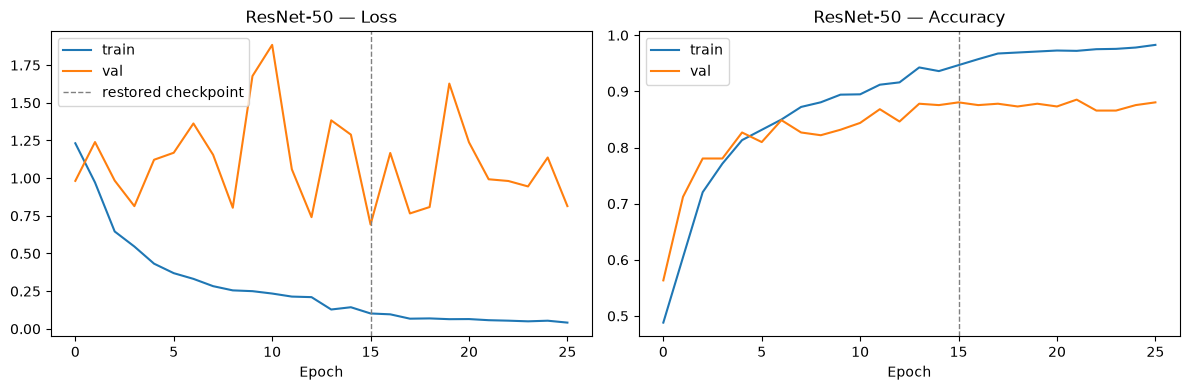

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.780


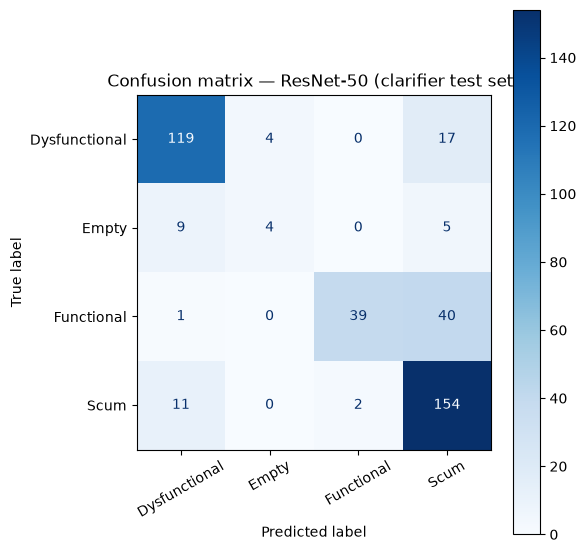

               precision    recall  f1-score   support

Dysfunctional      0.850     0.850     0.850       140
        Empty      0.500     0.222     0.308        18
   Functional      0.951     0.487     0.645        80
         Scum      0.713     0.922     0.804       167

     accuracy                          0.780       405
    macro avg      0.754     0.620     0.652       405
 weighted avg      0.798     0.780     0.766       405



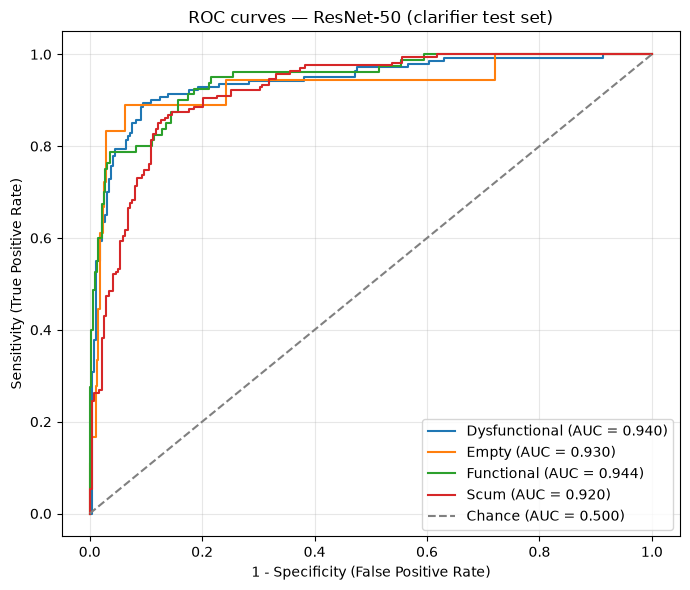

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.940
  Empty          : 0.930
  Functional     : 0.944
  Scum           : 0.920

Mean AUC (over 4/4 classes with test examples): 0.934


(np.float64(0.7802469135802469),
 {'Dysfunctional': 0.9400539083557952,
  'Empty': 0.9303761125466551,
  'Functional': 0.9442307692307693,
  'Scum': 0.9202687062849092})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
